In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r'D:\PYTHON PROJECTS\LIVER PATIENT ANALYSIS\DATASET\cleaned_liver_patient_dataset.csv',encoding='latin1')

print(df.head(10))

   age  gender    tb   db  alkphos  sgpt  sgot   tp  alb  a/g_ratio  target  \
0   65       0   0.7  0.1      187    16    18  6.8  3.3       0.90       1   
1   62       1  10.9  5.5      699    64   100  7.5  3.2       0.74       1   
2   62       1   7.3  4.1      490    60    68  7.0  3.3       0.89       1   
3   58       1   1.0  0.4      182    14    20  6.8  3.4       1.00       1   
4   72       1   3.9  2.0      195    27    59  7.3  2.4       0.40       1   
5   46       1   1.8  0.7      208    19    14  7.6  4.4       1.30       1   
6   26       0   0.9  0.2      154    16    12  7.0  3.5       1.00       1   
7   29       0   0.9  0.3      202    14    11  6.7  3.6       1.10       1   
8   17       1   0.9  0.3      202    22    19  7.4  4.1       1.20       0   
9   55       1   0.7  0.2      290    53    58  6.8  3.4       1.00       1   

   sgpt_sgot_ratio age_group  
0         0.842105    Senior  
1         0.633663    Senior  
2         0.869565    Senior  
3     

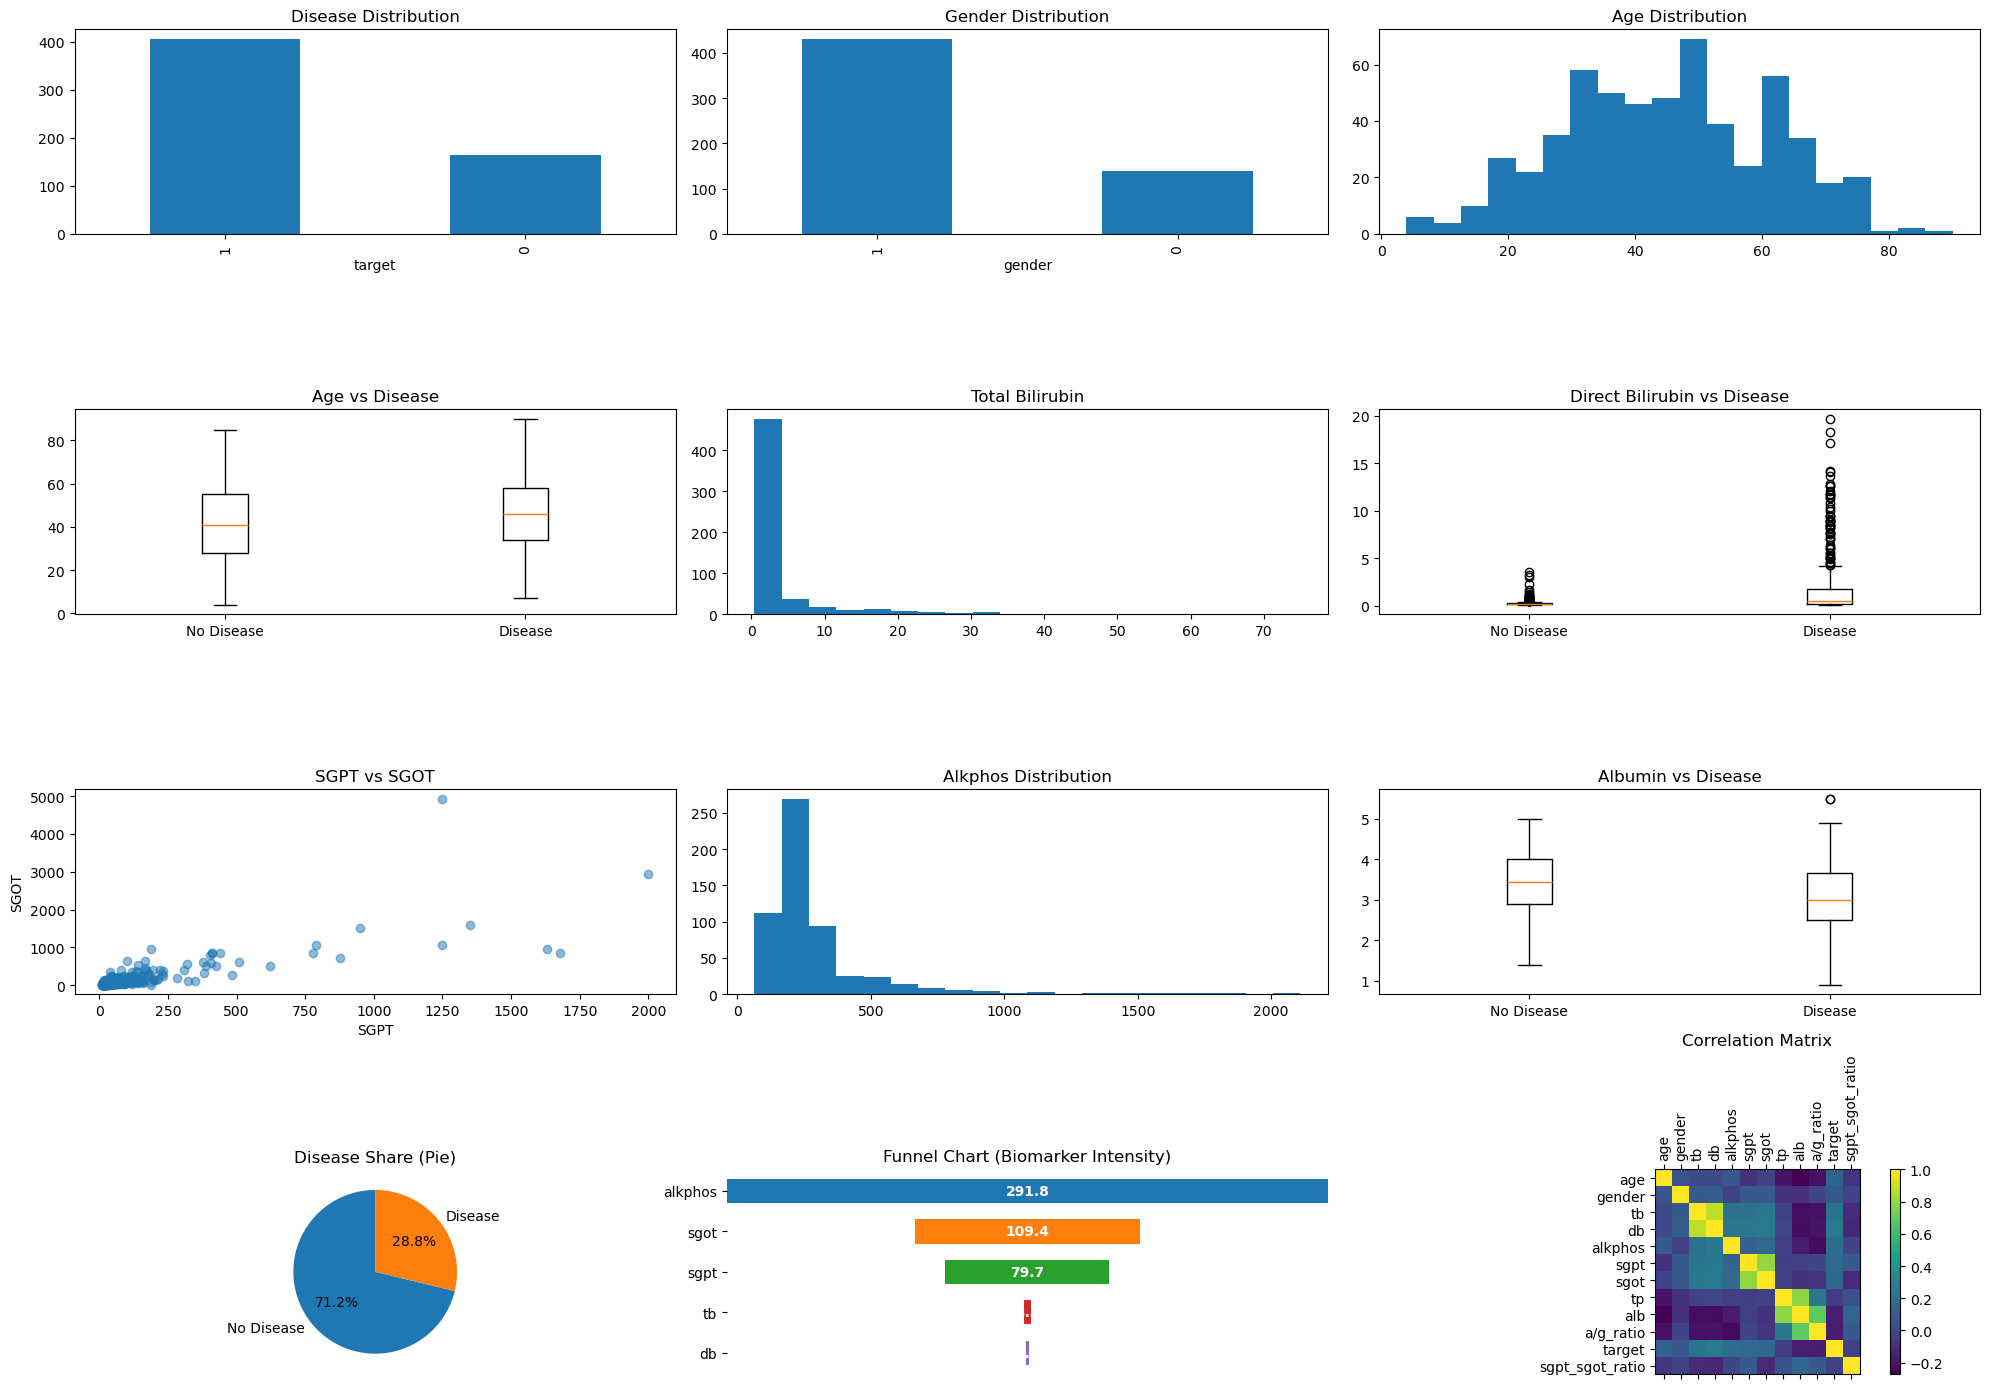

In [3]:
# Create figure
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3)

# 🔹 1. Target Distribution
ax1 = fig.add_subplot(gs[0, 0])
df['target'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_title("Disease Distribution")

# 🔹 2. Gender Distribution
ax2 = fig.add_subplot(gs[0, 1])
df['gender'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_title("Gender Distribution")

# 🔹 3. Age Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['age'], bins=20)
ax3.set_title("Age Distribution")

# 🔹 4. Age vs Disease (Boxplot)
ax4 = fig.add_subplot(gs[1, 0])
ax4.boxplot([df[df['target']==0]['age'], df[df['target']==1]['age']])
ax4.set_xticklabels(['No Disease', 'Disease'])
ax4.set_title("Age vs Disease")

# 🔹 5. Total Bilirubin Distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df['tb'], bins=20)
ax5.set_title("Total Bilirubin")

# 🔹 6. Direct Bilirubin vs Disease
ax6 = fig.add_subplot(gs[1, 2])
ax6.boxplot([df[df['target']==0]['db'], df[df['target']==1]['db']])
ax6.set_xticklabels(['No Disease', 'Disease'])
ax6.set_title("Direct Bilirubin vs Disease")

# 🔹 7. SGPT vs SGOT (Scatter)
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(df['sgpt'], df['sgot'], alpha=0.5)
ax7.set_xlabel("SGPT")
ax7.set_ylabel("SGOT")
ax7.set_title("SGPT vs SGOT")

# 🔹 8. Alkaline Phosphotase Distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(df['alkphos'], bins=20)
ax8.set_title("Alkphos Distribution")

# 🔹 9. Albumin vs Disease
ax9 = fig.add_subplot(gs[2, 2])
ax9.boxplot([df[df['target']==0]['alb'], df[df['target']==1]['alb']])
ax9.set_xticklabels(['No Disease', 'Disease'])
ax9.set_title("Albumin vs Disease")

# 🔹 10. Correlation Heatmap (Manual)
ax10 = fig.add_subplot(gs[3, 2])
corr = df.select_dtypes(include=np.number).corr()

cax = ax10.matshow(corr)
fig.colorbar(cax)

ax10.set_xticks(range(len(corr.columns)))
ax10.set_yticks(range(len(corr.columns)))

ax10.set_xticklabels(corr.columns, rotation=90)
ax10.set_yticklabels(corr.columns)

ax10.set_title("Correlation Matrix")

# 🔹 11. Pie Chart
ax11 = fig.add_subplot(gs[3, 0])

counts = df['target'].value_counts()
labels = ['No Disease', 'Disease']

ax11.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
ax11.set_title("Disease Share (Pie)")

# 🔹 12. Funnel Chart
ax12 = fig.add_subplot(gs[3, 1])

# Prepare funnel data (sorted)
funnel_data = df[['tb','db','alkphos','sgpt','sgot']].mean().sort_values(ascending=False)

labels = funnel_data.index.tolist()
values = funnel_data.values

# Normalize widths for better visual shape
max_val = values.max()
widths = values / max_val

# Positions
y_pos = np.arange(len(values))

# Draw centered bars
for i in range(len(values)):
    ax12.barh(
        y=y_pos[i],
        width=widths[i],
        left=(1 - widths[i]) / 2,  # center alignment
        height=0.6
    )
    
    # Add value text inside
    ax12.text(
        0.5, y_pos[i],
        f"{values[i]:.1f}",
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Y labels
ax12.set_yticks(y_pos)
ax12.set_yticklabels(labels)

# Remove x-axis
ax12.set_xticks([])
ax12.set_xlim(0, 1)

# Invert for funnel top-down
ax12.invert_yaxis()

# Clean look
for spine in ax12.spines.values():
    spine.set_visible(False)

ax12.set_title("Funnel Chart (Biomarker Intensity)", fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()